# Ensemble Study Notebook

This notebook inspects **per-detector signals** (rules, anomaly, ML, forecast) and tests different **ensemble strategies** on top of your existing Scenario-1 alerts.

Assumptions:
- Alerts are stored at: `out/r5.2/alerts_full/alerts.ndjson`
- `daily_user.parquet` lives at: `out/r5.2/features_v2/daily_user/daily_user.parquet`
- `answers/insiders.csv` exists with `dataset`, `scenario`, `user`, `start`, `end`.

You can run this end-to-end to get **empirical evidence** for:
- when each detector should fire,
- which detector combinations are strongest,
- and how to weight detector scores in an ensemble.


In [9]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
)

# Paths (relative to repo root)
ALERTS_PATH = Path("/Users/jordanchambers/capstone_6019/out/r5.2/alerts_full/alerts.ndjson")
DAILY_USER_PATH = Path("out/r5.2/features_v2/daily_user/daily_user.parquet")
INSIDERS_CSV = Path("/Users/jordanchambers/capstone_6019/answers/insiders.csv")

print("ALERTS_PATH:", ALERTS_PATH.resolve())
print("DAILY_USER_PATH:", DAILY_USER_PATH.resolve())
print("INSIDERS_CSV:", INSIDERS_CSV.resolve())

ALERTS_PATH: /Users/jordanchambers/capstone_6019/out/r5.2/alerts_full/alerts.ndjson
DAILY_USER_PATH: /Users/jordanchambers/capstone_6019/notebooks/analysis/out/r5.2/features_v2/daily_user/daily_user.parquet
INSIDERS_CSV: /Users/jordanchambers/capstone_6019/answers/insiders.csv


## 1. Load Scenario‑1 ground truth

We build a table of **(user_key, day)** with labels indicating whether the user is in the **Scenario‑1 exfil window** on that day.

- `label_exfil_window = 1` if the day is between `exfil_start` and `exfil_end` (inclusive).
- `label_pre7 = 1` if the day is within the 7‑day **pre‑exfil** window (for forecasting analysis).

In [10]:
# Load insiders ground truth
insiders = (
    pd.read_csv(INSIDERS_CSV)
      .query("dataset == 5.2 and scenario == 1")
      .copy()
)

# Normalize
insiders["user_key"] = insiders["user"].str.lower()
insiders["exfil_start"] = pd.to_datetime(insiders["start"], format="%m/%d/%Y %H:%M:%S")
insiders["exfil_end"] = pd.to_datetime(insiders["end"], format="%m/%d/%Y %H:%M:%S")

insiders = insiders[["user_key", "exfil_start", "exfil_end"]].reset_index(drop=True)
insiders

,user_key,exfil_start,exfil_end
0,alt1465,2010-08-13 22:16:10,2010-08-20 04:01:32
1,alw0764,2011-02-03 07:09:09,2011-02-05 06:12:51
2,ayg1697,2010-10-25 23:19:22,2010-10-26 00:06:28
3,das1320,2010-07-09 01:14:15,2010-07-15 01:38:58
4,dnj0740,2010-10-04 19:56:42,2010-10-05 01:01:37
5,elt1370,2011-02-03 18:23:53,2011-02-10 02:58:28
6,epg1196,2010-07-15 03:00:42,2010-07-20 00:19:48
7,etw0002,2011-03-17 00:59:27,2011-03-17 06:52:18
8,fzg0389,2010-12-10 21:50:34,2010-12-17 06:53:00
9,gfm1815,2010-07-16 22:00:57,2010-07-16 23:01:54


In [11]:
# Build a per-user/day label table for S1 insiders
rows = []
for _, r in insiders.iterrows():
    uk = r["user_key"]
    start = r["exfil_start"].normalize()
    end = r["exfil_end"].normalize()
    pre7_start = start - pd.Timedelta(days=7)

    d = pre7_start
    while d <= end:
        rows.append({
            "user_key": uk,
            "day": d,
            "label_exfil_window": int((d >= start) & (d <= end)),
            "label_pre7": int((d >= pre7_start) & (d < start)),
        })
        d += pd.Timedelta(days=1)

labels = pd.DataFrame(rows)
labels.head()

,user_key,day,label_exfil_window,label_pre7
0,alt1465,2010-08-06,0,1
1,alt1465,2010-08-07,0,1
2,alt1465,2010-08-08,0,1
3,alt1465,2010-08-09,0,1
4,alt1465,2010-08-10,0,1


## 2. Load alerts and build per‑day detector features

We collapse **per‑detector alerts** into a **per‑user/day** feature table, keeping:

- max rule score
- max ML score
- max anomaly score
- max forecast score
- whether any `s1_chain`, `s1_chain_post_departure`, or `s1_near_miss` fired


In [12]:
# Parse NDJSON alerts
records = []
with ALERTS_PATH.open() as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        if rec.get("detector") == "loop":
            continue
        records.append(rec)

alerts = pd.DataFrame(records)
alerts["user_key"] = alerts["user_key"].str.lower()
alerts["day"] = pd.to_datetime(alerts["day"]).dt.normalize()

alerts.head()

,day,user_key,detector,reason,score,evidence,human_summary,rules_score,anomaly_score,forecast_score
0,2010-01-04,emr0269,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
1,2010-01-04,vrp0267,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
2,2010-01-05,emr0269,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 3, 'usb_days_7d': 4, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
3,2010-01-05,ezb0925,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 1, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
4,2010-01-05,ocw1127,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN


In [14]:
# Build per-user/day detector features
def build_daily_detector_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Rule flags (computed once on the full frame)
    df["rule_s1_chain"] = df["reason"].eq("rules:s1_chain")
    df["rule_s1_chain_post_dep"] = df["reason"].eq("rules:s1_chain_post_departure")
    df["rule_s1_near_miss"] = df["reason"].eq("rules:s1_near_miss")

    # Helper that works *within* a group
    def max_score(group: pd.DataFrame, detector_name: str):
        sub = group[group["detector"] == detector_name]
        return sub["score"].max() if not sub.empty else np.nan

    rows = []
    for (uk, day), grp in df.groupby(["user_key", "day"]):
        rows.append({
            "user_key": uk,
            "day": day,
            "rules_max":    max_score(grp, "rules"),
            "ml_max":       max_score(grp, "ml"),
            "anomaly_max":  max_score(grp, "anomaly"),
            "forecast_max": max_score(grp, "forecast"),
            "rule_chain":            grp["rule_s1_chain"].any(),
            "rule_chain_post_dep":   grp["rule_s1_chain_post_dep"].any(),
            "rule_near_miss":        grp["rule_s1_near_miss"].any(),
        })

    return pd.DataFrame(rows)

daily_det = build_daily_detector_features(alerts)
daily_det.head()

,user_key,day,rules_max,ml_max,anomaly_max,forecast_max,rule_chain,rule_chain_post_dep,rule_near_miss
0,aab1302,2010-01-09,NaN,NaN,0.582153,NaN,False,False,False
1,aab1302,2010-01-11,NaN,NaN,0.605632,NaN,False,False,False
2,aab1302,2010-01-12,NaN,NaN,0.611579,NaN,False,False,False
3,aab1302,2010-01-13,NaN,NaN,0.612188,NaN,False,False,False
4,aab1302,2010-01-14,NaN,NaN,0.622541,NaN,False,False,False


## 3. Join detector signals with exfil labels

For now we restrict to **Scenario‑1 insiders only** to study *how the detectors behave around real exfil events*.

In [15]:
# Restrict detector table to insiders of interest
det_insiders = daily_det.merge(
    insiders[["user_key"]], on="user_key", how="inner"
)

# Join labels; missing labels = 0
det_labeled = det_insiders.merge(
    labels, on=["user_key", "day"], how="left"
)

det_labeled["label_exfil_window"] = det_labeled["label_exfil_window"].fillna(0).astype(int)
det_labeled["label_pre7"] = det_labeled["label_pre7"].fillna(0).astype(int)

det_labeled.sort_values(["user_key", "day"]).head()

,user_key,day,rules_max,ml_max,anomaly_max,forecast_max,rule_chain,rule_chain_post_dep,rule_near_miss,label_exfil_window,label_pre7
0,alt1465,2010-08-11,NaN,NaN,0.639483,0.908962,False,False,False,0,1
1,alt1465,2010-08-12,NaN,NaN,0.643570,0.903343,False,False,False,0,1
2,alt1465,2010-08-13,NaN,0.544195,0.673463,0.808813,False,False,False,1,0
3,alt1465,2010-08-14,0.8,0.994949,0.735772,0.649446,True,False,False,1,0
4,alt1465,2010-08-16,NaN,NaN,0.746329,0.647943,False,False,False,1,0


## 4. Basic sanity plots

Quick sanity checks:
- Detector score distributions inside vs. outside the exfil window.
- How often each rule type fires around exfil.

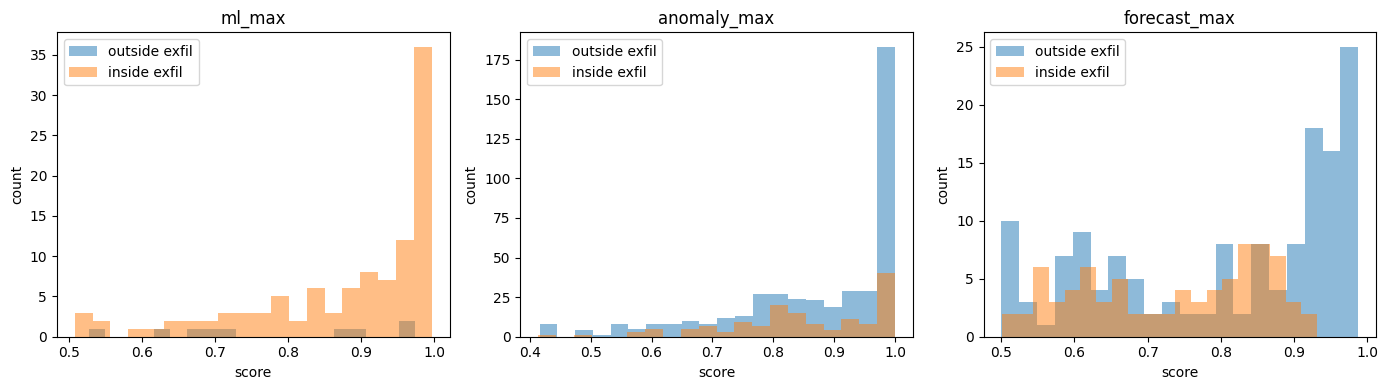

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))

for ax, col in zip(axes, ["ml_max", "anomaly_max", "forecast_max"]):
    pos = det_labeled.loc[det_labeled["label_exfil_window"] == 1, col].dropna()
    neg = det_labeled.loc[det_labeled["label_exfil_window"] == 0, col].dropna()

    ax.hist(neg, bins=20, alpha=0.5, label="outside exfil")
    ax.hist(pos, bins=20, alpha=0.5, label="inside exfil")
    ax.set_title(col)
    ax.set_xlabel("score")
    ax.set_ylabel("count")
    ax.legend()

plt.tight_layout()
plt.show()

In [17]:
rule_counts = (
    det_labeled
    .groupby("label_exfil_window")[["rule_chain", "rule_chain_post_dep", "rule_near_miss"]]
    .sum()
)
rule_counts

,rule_chain,rule_chain_post_dep,rule_near_miss
label_exfil_window,,,
0,0,0,36
1,42,14,19


## 5. Logistic regression as ensemble oracle

We use logistic regression on top of raw per‑detector scores to estimate **how much each detector should matter**.

Features:
- `rules_full = 1` if `rule_chain` or `rule_chain_post_dep` fired
- `rules_near = 1` if `rule_near_miss` fired
- `ml_max`, `anomaly_max`, `forecast_max` (NaNs → 0)

Target:
- `label_exfil_window` (inside exfil window vs. not)

In [18]:
df = det_labeled.copy()

df["rules_full"] = (df["rule_chain"] | df["rule_chain_post_dep"]).astype(int)
df["rules_near"] = df["rule_near_miss"].astype(int)

for c in ["ml_max", "anomaly_max", "forecast_max"]:
    df[c] = df[c].fillna(0.0)

feature_cols = ["rules_full", "rules_near", "ml_max", "anomaly_max", "forecast_max"]
X = df[feature_cols].to_numpy()
y = df["label_exfil_window"].to_numpy()

print("X shape:", X.shape, "y positive rate:", y.mean())

X shape: (663, 5) y positive rate: 0.22171945701357465


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Features going into the ensemble oracle
features = ["rules_full", "rules_near", "ml_max", "anomaly_max", "forecast_max"]

X = det_labeled[features].to_numpy()
y = det_labeled["exfil_within_window"].astype(int).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    solver="liblinear",
)

logreg.fit(X_train, y_train)

coefs = (
    pd.DataFrame({"feature": features, "coef": logreg.coef_[0]})
    .sort_values("coef", ascending=False)
    .reset_index(drop=True)
)
intercept = float(logreg.intercept_[0])
coefs, intercept

(        feature      coef
 2        ml_max  4.776795
 0    rules_full  2.553178
 3   anomaly_max  1.240133
 4  forecast_max  1.117140
 1    rules_near -1.092871,
 -3.634722125361524)

Logistic ensemble ROC-AUC: 0.923
Logistic ensemble AP (PR-AUC): 0.876


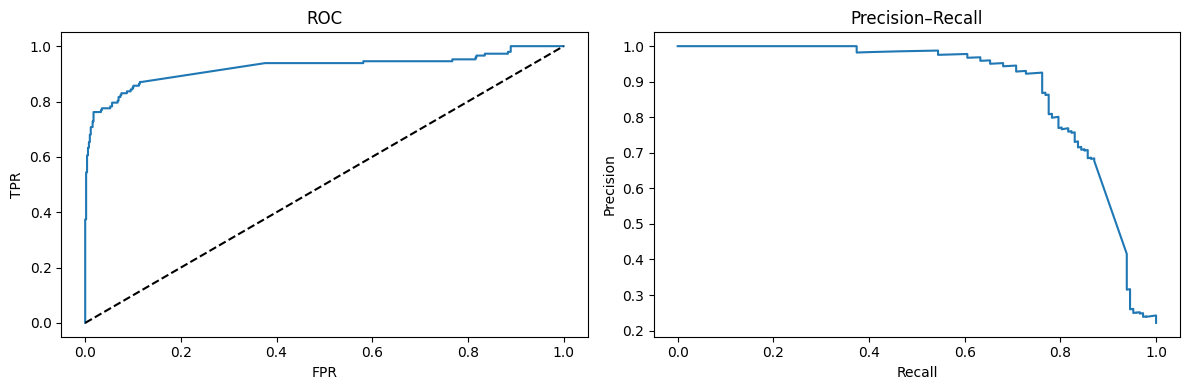

In [20]:
# Evaluate ROC / PR
probs = clf.predict_proba(X)[:, 1]

auc = roc_auc_score(y, probs)
ap = average_precision_score(y, probs)

print(f"Logistic ensemble ROC-AUC: {auc:.3f}")
print(f"Logistic ensemble AP (PR-AUC): {ap:.3f}")

fpr, tpr, ths = roc_curve(y, probs)
prec, rec, th_pr = precision_recall_curve(y, probs)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(fpr, tpr)
axes[0].plot([0,1], [0,1], "k--")
axes[0].set_title("ROC")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")

axes[1].plot(rec, prec)
axes[1].set_title("Precision–Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()

## 6. Threshold sweep: what counts as an escalation?

We can treat the logistic‑regression probability as a **candidate ensemble score**, then see what happens as we vary an escalation threshold.

This gives empirical guidance for rules like:
- "Escalate if ensemble ≥ 0.9"
- "Near‑miss + strong ML or forecast"
- "Anomaly alone should rarely escalate"


In [21]:
def sweep_thresholds(y_true, scores, n=20):
    thr_values = np.linspace(0.1, 0.99, n)
    rows = []
    for thr in thr_values:
        preds = (scores >= thr).astype(int)
        tp = int(((preds == 1) & (y_true == 1)).sum())
        fp = int(((preds == 1) & (y_true == 0)).sum())
        fn = int(((preds == 0) & (y_true == 1)).sum())

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        rows.append({
            "threshold": thr,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": prec,
            "recall": rec,
        })
    return pd.DataFrame(rows)

thr_table = sweep_thresholds(y, probs)
thr_table

,threshold,tp,fp,fn,precision,recall
0,0.100000,127,59,20,0.682796,0.863946
1,0.146842,120,38,27,0.759494,0.816327
2,0.193684,113,18,34,0.862595,0.768707
3,0.240526,112,9,35,0.925620,0.761905
4,0.287368,112,9,35,0.925620,0.761905
5,0.334211,112,9,35,0.925620,0.761905
6,0.381053,112,9,35,0.925620,0.761905
7,0.427895,111,9,36,0.925000,0.755102
8,0.474737,108,9,39,0.923077,0.734694
9,0.521579,107,9,40,0.922414,0.727891


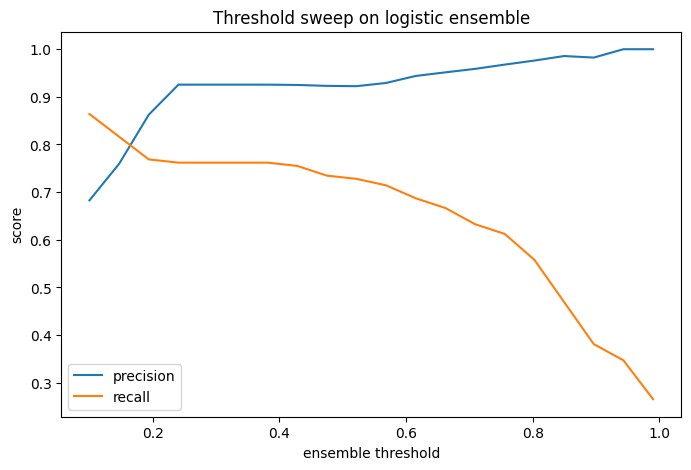

In [22]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(thr_table["threshold"], thr_table["precision"], label="precision")
ax.plot(thr_table["threshold"], thr_table["recall"], label="recall")
ax.set_xlabel("ensemble threshold")
ax.set_ylabel("score")
ax.set_title("Threshold sweep on logistic ensemble")
ax.legend()
plt.show()

## 7. Compare simple hand‑crafted ensemble rules

To justify or adjust your current `compute_ensemble` logic, we can compare a few **toy ensembles**:

1. `max_prong = max(ml_max, anomaly_max, forecast_max)`
2. `rules_or_ml = max(rules_full, ml_max)`
3. `rules_ml_forecast = max(rules_full, 0.7 * ml_max + 0.3 * forecast_max)`

We’ll measure ROC‑AUC and PR‑AUC for each and see which shape looks most sane.

In [23]:
def eval_ensemble(name, scores, y_true):
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    return {"name": name, "roc_auc": auc, "ap": ap}

ensembles = []

rules_full = df["rules_full"].to_numpy().astype(float)
ml_max = df["ml_max"].to_numpy()
anom_max = df["anomaly_max"].to_numpy()
fore_max = df["forecast_max"].to_numpy()

ensembles.append(eval_ensemble("logistic_oracle", probs, y))
ensembles.append(eval_ensemble("max_prong", np.maximum.reduce([ml_max, anom_max, fore_max]), y))
ensembles.append(eval_ensemble("rules_or_ml", np.maximum(rules_full, ml_max), y))
ensembles.append(eval_ensemble("rules_ml_forecast",
                               np.maximum(rules_full, 0.7 * ml_max + 0.3 * fore_max),
                               y))

pd.DataFrame(ensembles).sort_values("roc_auc", ascending=False)

,name,roc_auc,ap
0,logistic_oracle,0.922533,0.876424
3,rules_ml_forecast,0.895863,0.835472
2,rules_or_ml,0.876015,0.799560
1,max_prong,0.537019,0.223902


## 8. Per‑user timelines (optional debugging)

Helper function to reproduce the kind of per‑user trend plots you’ve been staring at,
but now directly from this notebook so you can overlay **ensemble scores** as well.

Example user: alt1465


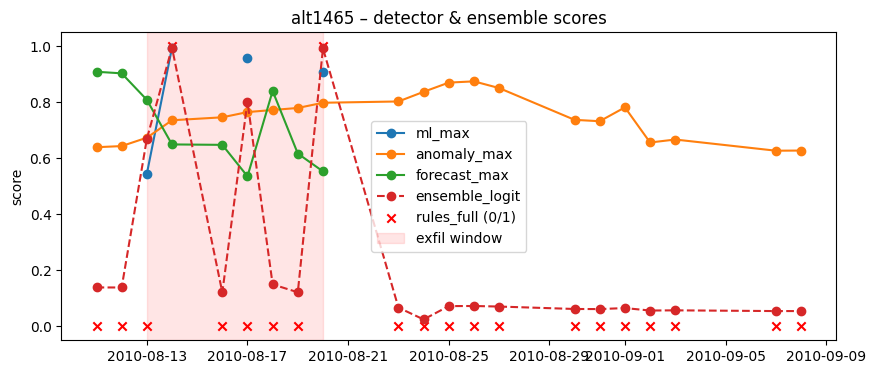

In [24]:
def plot_user_timeline(user_key: str):
    uk = user_key.lower()
    d = det_labeled[det_labeled["user_key"] == uk].copy()
    if d.empty:
        print("No data for", uk)
        return

    d = d.sort_values("day")
    d["rules_full"] = (d["rule_chain"] | d["rule_chain_post_dep"]).astype(int)

    # Merge logistic ensemble score
    d = d.merge(
        pd.DataFrame({
            "user_key": df["user_key"],
            "day": df["day"],
            "ensemble_logit": probs
        }),
        on=["user_key", "day"],
        how="left"
    )

    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(d["day"], d["ml_max"], label="ml_max", marker="o")
    ax.plot(d["day"], d["anomaly_max"], label="anomaly_max", marker="o")
    ax.plot(d["day"], d["forecast_max"], label="forecast_max", marker="o")
    ax.plot(d["day"], d["ensemble_logit"], label="ensemble_logit", marker="o", linestyle="--")
    ax.scatter(d["day"], d["rules_full"], label="rules_full (0/1)", color="red", marker="x")

    # Highlight exfil window
    gt = insiders[insiders["user_key"] == uk]
    if not gt.empty:
        s = gt.iloc[0]["exfil_start"].normalize()
        e = gt.iloc[0]["exfil_end"].normalize()
        ax.axvspan(s, e, color="red", alpha=0.1, label="exfil window")

    ax.set_title(f"{uk} – detector & ensemble scores")
    ax.set_ylabel("score")
    ax.legend()
    plt.show()

# Example (replace with any S1 insider you care about)
example_user = insiders["user_key"].iloc[0]
print("Example user:", example_user)
plot_user_timeline(example_user)

## 9. How to use this notebook to set ensemble rules

Once you’ve run everything, you can answer concrete questions like:

- Do we actually gain anything from anomaly in ROC/PR, or should it stay as “support only”?
- How much does forecast help for **pre‑7‑day** detection vs. within the exfil window?
- What escalation threshold on the logistic ensemble gives a reasonable TP / FP balance?
- Which simple hand‑crafted rule (e.g., `rules_or_ml`, `rules_ml_forecast`) matches the logistic oracle best?

From there you can translate the chosen strategy back into `compute_ensemble` in `src/ui/app.py` with actual numbers instead of vibes.


In [26]:
from pathlib import Path
import json, joblib
import os

# Make sure we are in the repo root:
os.chdir("/Users/jordanchambers/capstone_6019")

MODEL_DIR = Path("out/r5.2/ensemble_model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1) Save the trained logistic ensemble model
joblib.dump(clf, MODEL_DIR / "ensemble_logreg.pkl")

# 2) Save metadata: which features this model expects
meta = {
    "feature_cols": feature_cols,
    "note": "Logistic ensemble over [rules_max_7d, anomaly_max_7d, ml_max_7d, forecast_max_7d, any_rule_7d]",
}
with (MODEL_DIR / "ensemble_meta.json").open("w") as f:
    json.dump(meta, f, indent=2)

print("Saved ensemble model + meta to", MODEL_DIR)

Saved ensemble model + meta to out/r5.2/ensemble_model
